# LightGBM

In [108]:
import pandas as pd
import numpy as np
import os, joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, RocCurveDisplay
)
import warnings; warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data', 'processed_data.csv')
MODEL_DIR  = os.path.join(BASE_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

print('path:', DATA_PATH)

path: d:\School\msba\作业\5113\group\sg\data\processed_data.csv


## 1. read data

In [109]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'数据形状: {df.shape}  预订率: {df["booked"].mean():.2%}')

# listing_id 是标识符，不作为特征
FEATURES = [c for c in df.columns if c not in ['booked', 'listing_id']]
X = df[FEATURES]
y = df['booked']

# 按时序意义做分层抽样划分（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'训练集: {X_train.shape}  测试集: {X_test.shape}')

数据形状: (953380, 15)  预订率: 17.00%
训练集: (762704, 13)  测试集: (190676, 13)


## 2. train

In [110]:
# is_unbalance=True 自动处理类别不平衡
model = lgb.LGBMClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    num_leaves       = 63,
    max_depth        = -1,
    min_child_samples= 50,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    is_unbalance     = True,
    device           = 'gpu',       
    random_state     = 42,
    verbose          = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
print(f'最优迭代轮数: {model.best_iteration_}')

最优迭代轮数: 7


## 3. evaluate

In [111]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred)
print(f'AUC-ROC : {auc:.4f}')
print(f'F1 Score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['not booked','booked']))

AUC-ROC : 0.8276
F1 Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

  not booked       0.83      1.00      0.91    158262
      booked       0.00      0.00      0.00     32414

    accuracy                           0.83    190676
   macro avg       0.42      0.50      0.45    190676
weighted avg       0.69      0.83      0.75    190676



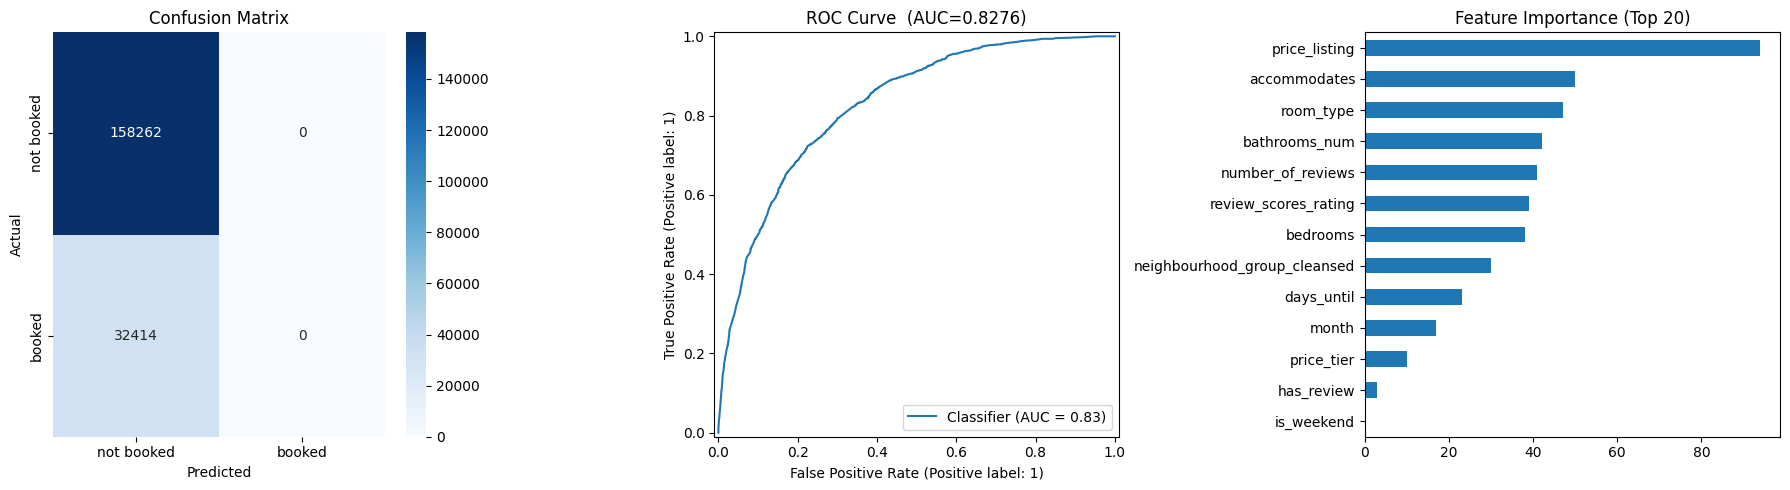

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['not booked','booked'],
            yticklabels=['not booked','booked'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve  (AUC={auc:.4f})')

imp = pd.Series(model.feature_importances_, index=FEATURES).nlargest(20)
imp.sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Feature Importance (Top 20)')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'lgbm_eval.png'), dpi=120)
plt.show()

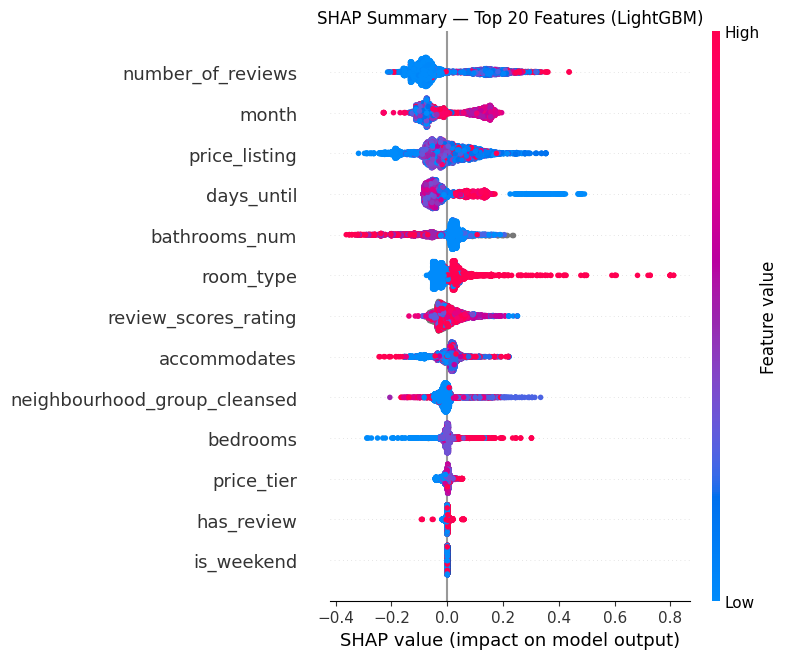

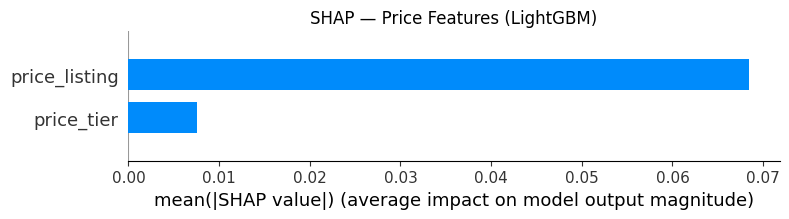

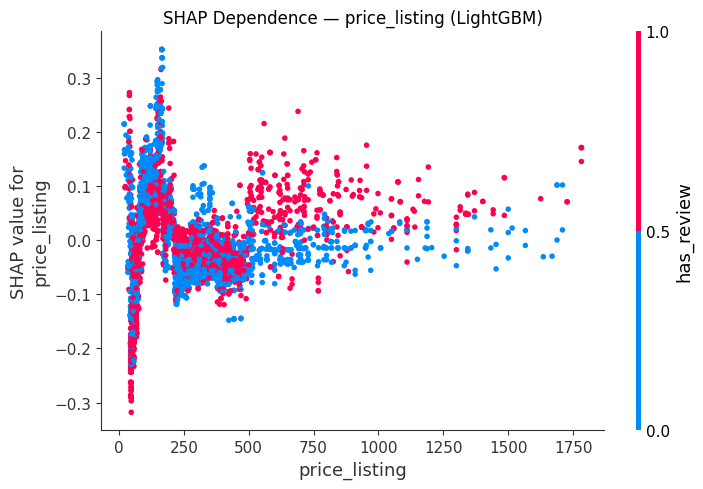

In [113]:
# ── Price 相关特征的全局 SHAP 分析 ────────────────────────────
import shap

# 数据量大，取样加速（5000 条足够反映全局规律）
sample_idx = X_test.sample(5000, random_state=42).index
X_shap = X_test.loc[sample_idx][FEATURES]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
# LightGBM 二分类返回 list[neg, pos]，取正类
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# ── 1. 全局 Beeswarm（所有特征，高亮价格列位置）──────────────
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features (LightGBM)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'lgbm_shap_summary.png'), dpi=120)
plt.show()

# ── 2. 仅看 price 相关列的 bar chart ─────────────────────────
price_cols = [c for c in FEATURES if 'price' in c or 'revenue' in c]
price_idx  = [FEATURES.index(c) for c in price_cols]

shap.summary_plot(sv[:, price_idx], X_shap[price_cols],
                  plot_type='bar', show=False)
plt.title('SHAP — Price Features (LightGBM)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'lgbm_shap_price_bar.png'), dpi=120)
plt.show()

# ── 3. price_listing 的 dependence plot ──────────────────────
if 'price_listing' in FEATURES:
    shap.dependence_plot('price_listing', sv, X_shap, show=False)
    plt.title('SHAP Dependence — price_listing (LightGBM)')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'lgbm_shap_price_dep.png'), dpi=120)
    plt.show()

## 5. predict example

In [114]:
sample = X_test.sample(5, random_state=0).copy()
sample['actual_booked']    = y_test.loc[sample.index].values
sample['pred_probability'] = model.predict_proba(sample[FEATURES])[:, 1].round(4)

show_cols = ['days_until', 'day_of_week', 'is_weekend', 'month',
             'room_type', 'neighbourhood_group_cleansed',
             'price_listing', 'review_scores_rating',
             'actual_booked', 'pred_probability']
show_cols = [c for c in show_cols if c in sample.columns]

sample[show_cols].reset_index(drop=True)

,days_until,is_weekend,month,room_type,neighbourhood_group_cleansed,price_listing,review_scores_rating,actual_booked,pred_probability
0,243,0,5,0,0,935.0,5.00,0,0.1737
1,291,0,7,0,0,276.0,NaN,0,0.2540
2,330,0,8,2,0,88.0,4.25,0,0.3392
3,326,0,8,2,0,205.0,5.00,0,0.3119
4,363,1,9,2,0,154.0,NaN,0,0.3451


## 4. save

In [115]:
# 保存模型（joblib pkl，含 feature list，后续直接 load 推理）
model_path = os.path.join(MODEL_DIR, 'lgbm_model.pkl')
joblib.dump({'model': model, 'features': FEATURES}, model_path)
print(f'模型已保存: {model_path}')

模型已保存: d:\School\msba\作业\5113\group\sg\model\lgbm_model.pkl


In [116]:
# ── 推理示例：load pkl → 输出预订概率 ────────────────────────
saved = joblib.load(os.path.join(MODEL_DIR, 'lgbm_model.pkl'))
loaded_model    = saved['model']
loaded_features = saved['features']

# 取测试集中 3 条作为"新数据"模拟推理
new_data = X_test.iloc[:3][loaded_features].copy()
probs = loaded_model.predict_proba(new_data)[:, 1]

result = new_data[['days_until', 'is_weekend', 'room_type',
                   'price_listing']].copy()
result['pred_prob_booked'] = probs.round(4)
print('=== 推理示例（load pkl）===')
result.reset_index(drop=True)

=== 推理示例（load pkl）===


,days_until,is_weekend,room_type,price_listing,pred_prob_booked
0,83,1,2,69.0,0.2146
1,151,0,0,910.0,0.1688
2,250,0,2,170.0,0.2486


In [117]:
import pandas as pd
import joblib, os


model    = saved['model']
features = saved['features']

# 手动构造一条输入（值参考 processed_data.csv 的实际范围）
row = pd.DataFrame([{
    'days_until'                  : 30,
    'day_of_week'                 : 5,
    'is_weekend'                  : 1,
    'month'                       : 7,
    'quarter'                     : 3,
    'day_of_year'                 : 200,
    'room_type'                   : 1,      # label encoded
    'neighbourhood_group_cleansed': 2,      # label encoded
    'neighbourhood_cleansed'      : 10,     # label encoded
    'property_type'               : 3,      # label encoded
    'price_listing'               : 2000,
    'accommodates'                : 2,
    'bedrooms'                    : 1,
    'beds'                        : 1,
    'bathrooms_num'               : 1.0,
    'review_scores_rating'        : 4.8,
    'number_of_reviews'           : 50,
    'has_review'                  : 1,
    # ... 其余列填 NaN，树模型会自动处理
}])

# 对齐所有训练特征，缺失的列补 NaN
row = row.reindex(columns=features)

prob = model.predict_proba(row)[0, 1]
print(f'预订概率: {prob:.4f}')


预订概率: 0.3627
